In [1]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import math

In [2]:
a = np.array([1,2,3,4])

In [3]:
a[0:3]

array([1, 2, 3])

In [61]:
def Simple_LID_data(n=2500, lid=1, dim=2):
    res = np.empty((n, dim))
    for i in range(n):
        if lid > 1:
            U = np.random.uniform(size=lid-1)
            u = np.random.uniform(size=1)
            res[i][:lid-1] = U[0:lid-1]
            res[i][lid-1:] = u
        else:
            u = np.random.uniform(size=1)
            res[i] = u
    return res, lid, dim

In [65]:
float(None)

TypeError: float() argument must be a string or a real number, not 'NoneType'

In [62]:
d, _, _ = Simple_LID_data(n=2500, lid=2, dim=3)

In [63]:
d

array([[0.09065316, 0.44135592, 0.44135592],
       [0.79905872, 0.42676024, 0.42676024],
       [0.07117768, 0.26645858, 0.26645858],
       ...,
       [0.67282843, 0.97314738, 0.97314738],
       [0.02555337, 0.37659203, 0.37659203],
       [0.41695554, 0.16450681, 0.16450681]])

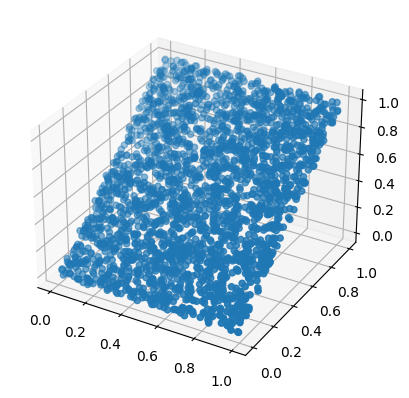

In [64]:
ax = plt.axes(projection='3d')
ax.scatter(d[:,0], d[:,1], d[:,2])

In [5]:
def weight_assign(weights):
    def f(i, k = None, weights = weights):
        return weights[i]
    return f

In [44]:
def hypergeometric_test(n, sr, log=True, exp=True, weight_funct1=None,  weight_funct2=None):
    k = int(n*sr)
    A = np.array([i for i in range(k)])
    Y1 = np.array([stats.hypergeom.pmf(a, M=n, n=k, N=k) for a in A])
    y1 = np.array([weight_funct1(a, k) for a in A])
    #print(np.sum(Y1[int(k*sr-2*np.sqrt(k*(1-sr)*sr)):int(k*sr+2*np.sqrt(k*(1-sr)*sr))]))
    #print(np.sum(y1[int(k*sr-2*np.sqrt(k*(1-sr)*sr)):int(k*sr+2*np.sqrt(k*(1-sr)*sr))]))
    print(np.sum(Y1*y1))
    #print(np.sum(y2[int(k*sr-2*np.sqrt(k*(1-sr)*sr)):int(k*sr+2*np.sqrt(k*(1-sr)*sr))]))
    if log:
        Y1 = np.log(Y1)
        y1 = np.log(y1)
    if exp:
        Y1 = np.exp(Y1)
        y1 = np.exp(y1)
    plt.plot(A, Y1, label='p')
    plt.plot(A, y1, label='w')
    plt.legend()
    plt.show()

In [53]:
def hypergeometric_test2(n, sr, log=True, exp=True, weight_funct1=None, weight_funct2=None):
    l = len(sr)
    k = [int(n * s) for s in sr]
    A = [np.array([i for i in range(k[i])]) for i in range(l)]
    Y = [np.array([stats.hypergeom.pmf(a, M=n, n=k[i], N=k[i]) for a in A[i]]) for i in range(l)]
    y = [np.array([weight_funct1(a, k[i]) for a in A[i]]) for i in range(l)]
    #print(np.sum(Y1[int(k*sr-2*np.sqrt(k*(1-sr)*sr)):int(k*sr+2*np.sqrt(k*(1-sr)*sr))]))
    #print(np.sum(y1[int(k*sr-2*np.sqrt(k*(1-sr)*sr)):int(k*sr+2*np.sqrt(k*(1-sr)*sr))]))
    print([f'sr_{sr[i]}_{np.sum(Y[i] * y[i])}' for i in range(l)])
    #print(np.sum(y2[int(k*sr-2*np.sqrt(k*(1-sr)*sr)):int(k*sr+2*np.sqrt(k*(1-sr)*sr))]))
    if log:
        Y = np.log(Y)
        y = np.log(y)
    if exp:
        Y = np.exp(Y)
        y = np.exp(y)
    for i in range(l):
        plt.plot(A[i], Y[i], label=f'p_sr_{sr[i]}')
        plt.plot(A[i], y[i], label=f'w_sr_{sr[i]}')
    plt.legend()
    plt.show()

In [7]:
def sr_test(n, N = 100, start = 0.01, stop = 0.90, log=True, exp=True, weight_funct1=None, p=-2, t=2):
    if weight_funct1 is None:
        weight_funct1 = basic_weight_funct(c=1, p=p, t=t)
    log_points = np.log10([start, stop])
    sr = np.logspace(log_points[0], log_points[1], num=N)
    K = [int(n*s) for s in sr]
    Y = [sum([stats.hypergeom.pmf(a, M=n, n=int(n*s), N=int(n*s))*weight_funct1(a, int(n*s)) for a in range(int(n*s))]) for s in tqdm(sr)]
    #Z = [weight_funct1(int(n*s**2), int(n*s)) for s in sr]
    F = [s**(2*t+p)*n**(t+p) for s in sr]
    if log:
        Y = np.log(Y)
        F = np.log(F)
    if exp:
        Y = np.exp(Y)
        F = np.exp(F)
    plt.plot(sr, Y, label='var')
    #plt.plot(sr, Z, label='mean_var')
    plt.plot(sr, F, label='reference')
    plt.legend()
    plt.show()

In [12]:
def sr_mean_var_test(n, I = 100, log = True):
    start, stop, N = 0.01, 0.90, I
    log_points = np.log10([start, stop])
    sr = np.logspace(log_points[0], log_points[1], num=N)
    mean = np.array([n*s**2 for s in sr])
    var = np.array([n*s**2*(1-s) for s in sr])
    if log:
        plt.plot(sr, np.log(mean), label='mean')
        plt.plot(sr, np.log(var), label='var')
        plt.plot(sr, np.log(var/mean), label='ratio')
    else:
        plt.plot(sr, mean, label='mean')
        plt.plot(sr, var, label='var')
        plt.plot(sr, var/mean, label='ratio')
    plt.legend()
    plt.show()

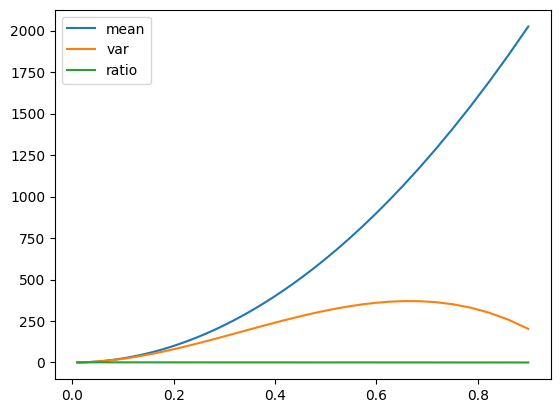

In [13]:
sr_mean_var_test(2500, I = 100, log = False)

  0%|          | 0/100 [00:00<?, ?it/s]

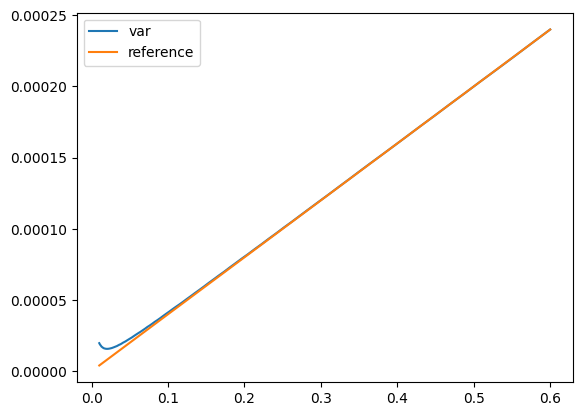

In [19]:
sr_test(n=2500, start = 0.01, stop = 0.6, N = 100, log=False, exp=False, p=-3, t=2, weight_funct1=None)

In [31]:
f1 = basic_weight_funct(c=100, p=-3, t=2)

0.008051220488195275


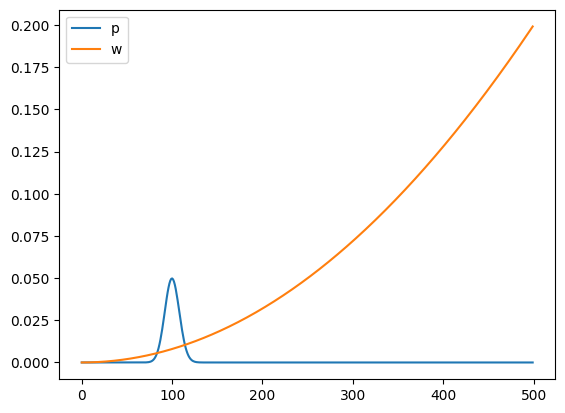

In [45]:
hypergeometric_test(n=2500, sr=0.2, log=False, exp=False, weight_funct1=f1)

0.01601440576230491


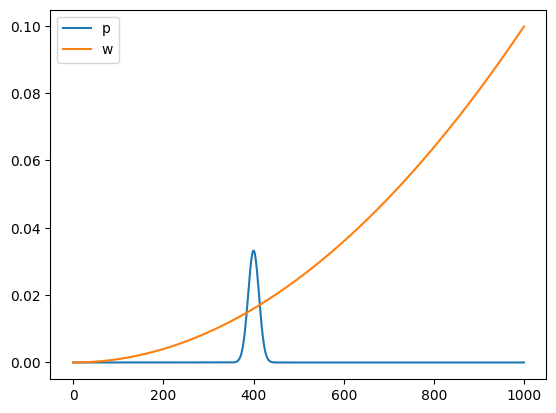

In [46]:
hypergeometric_test(n=2500, sr=0.4, log=False, exp=False, weight_funct1=f1)

0.024004268374016247


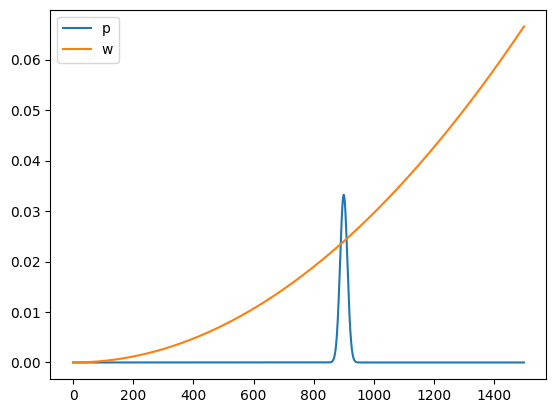

In [47]:
hypergeometric_test(n=2500, sr=0.6, log=False, exp=False, weight_funct1=f1)

0.03200080032012804


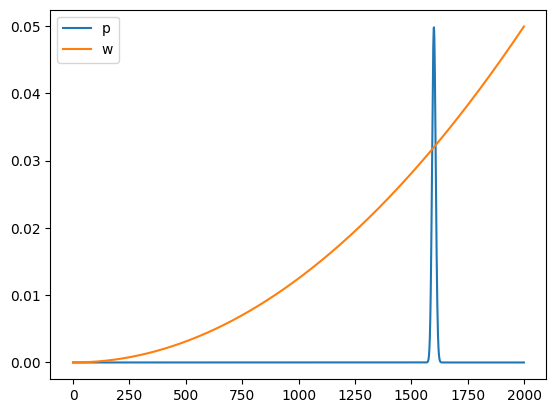

In [48]:
hypergeometric_test(n=2500, sr=0.8, log=False, exp=False, weight_funct1=f1)

['sr_0.2_0.008051220488195275', 'sr_0.4_0.01601440576230491', 'sr_0.6_0.024004268374016247', 'sr_0.8_0.03200080032012804']


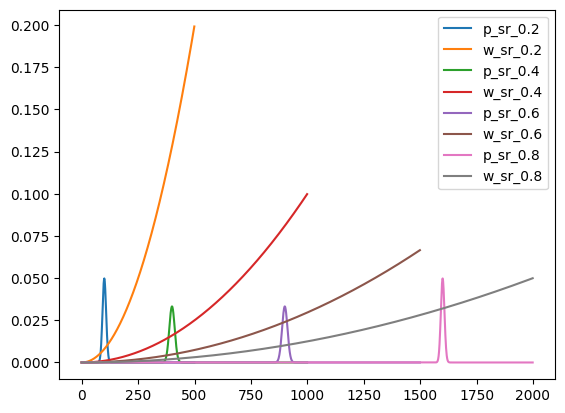

In [54]:
hypergeometric_test2(n=2500, sr=[0.2,0.4,0.6,0.8], log=False, exp=False, weight_funct1=f1)